# PyTorch

## Instalación de dependencias

In [1]:
%%capture
uv pip install torch torchvision numpy matplotlib scikit-learn seaborn

## Importar librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

## Importar imágenes 

In [3]:
from get_images import get_images

In [4]:
# MNIST path
mnist_path = '../data/mnist'
x_train_num, y_train_num, x_test_num, y_test_num = get_images(mnist_path)

x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)
y_train = y_train_num[:50000].reshape(50000, 1)

x_val = x_train_num[50000:].reshape(10000, -1).astype(np.float32)
y_val = y_train_num[50000:].reshape(10000, 1)

x_test = x_test_num.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test_num.copy().reshape(10000, 1)

## Normalizar imágenes

$$x_n= (x - μ) / σ$$

Donde:
- $μ$ = media de todo el training set
- $σ$ = desviación estándar del training set

In [5]:
def normalise(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

In [6]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)

In [7]:
x_train.mean(), x_train.std()

(np.float32(9.0680805e-09), np.float32(1.0))

## Mostrar imágenes 

In [8]:
x_test.shape

(10000, 784)

In [9]:
y_train.shape

(50000, 1)

In [10]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

La imagen muestreada representa un: 8


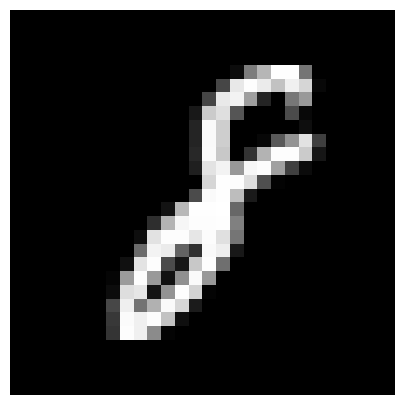

In [11]:
rnd_idx = np.random.randint(len(y_test))
print(f'La imagen muestreada representa un: {y_test[rnd_idx, 0]}')
plot_number(x_test_num[rnd_idx])

## PyTorch

## Convertir Numpy array a PyTorch (Tensores)

Un **tensor** es como un arreglo multidimensional de números. Es la forma en que PyTorch almacenan y procesa datos.

In [12]:
x_train_tensor = torch.tensor(x_train.copy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.copy(), dtype=torch.long).squeeze()

x_val_tensor = torch.tensor(x_val.copy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.copy(), dtype=torch.long).squeeze()

x_test_tensor = torch.tensor(x_test.copy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.copy(), dtype=torch.long).squeeze()

## Usar GPU de estar disponible

In [13]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
print(f'Dispositivo seleccionado: {device}')

GPU disponible: NVIDIA RTX A2000 Laptop GPU
Dispositivo seleccionado: cuda


In [14]:
print(f'Train: {x_train_tensor.shape}, {y_train_tensor.shape}')
print(f'Val: {x_val_tensor.shape}, {y_val_tensor.shape}')
print(f'Test: {x_test_tensor.shape}, {y_test_tensor.shape}')

Train: torch.Size([50000, 784]), torch.Size([50000])
Val: torch.Size([10000, 784]), torch.Size([10000])
Test: torch.Size([10000, 784]), torch.Size([10000])


## Crear DataLoaders de PyTorch

Un **DataLoader** es como un "repartidor de datos" que entrega tus datos en pequeños lotes (batches) durante el entrenamiento.

In [15]:
# Crear datasets
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# Configuración de batch size
batch_size = 512

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Batches de entrenamiento: {len(train_loader)}')
print(f'Batches de validación: {len(val_loader)}')
print(f'Batches de test: {len(test_loader)}')

Batches de entrenamiento: 98
Batches de validación: 20
Batches de test: 20


## Función de evaluación

In [16]:
def evaluate(model, data_loader, device):
    """
    Evalúa el modelo en un DataLoader y retorna accuracy y loss promedio
    """
    correct = 0
    total = 0
    total_loss = 0.0
    model = model.to(device=device)
    
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
        
            outputs = model(x_batch)
            loss = F.cross_entropy(outputs, y_batch)
            total_loss += loss.item()
            
            _, predicted = outputs.max(dim=1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    
    accuracy = correct / total
    avg_loss = total_loss / len(data_loader)
    return accuracy, avg_loss

## Loop de entrenamiento

In [17]:
def train_model(model, train_loader, val_loader, optimizer, device):
    """
    Entrena el modelo usando PyTorch DataLoaders
    """
    model = model.to(device)
    val_acc = 0
    epoch = 0
    while val_acc <= 0.95:

        model.train()
        
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Forward pass
            outputs = model(x_batch)
            loss = F.cross_entropy(outputs, y_batch)
            
            # Backward pass
            optimizer.zero_grad() # Limpia los gradientes acumulados
            loss.backward() # Calcula los gradientes
            optimizer.step() # Actualiza los pesos del modelo


        
        # Evaluar en validación
        val_acc, val_loss = evaluate(model, val_loader, device)
        train_acc, train_loss =  evaluate(model, train_loader, device)
        epoch +=1
        
        print(f'Epoch {epoch+1} - '
              f'Train Loss: {train_loss:.4f} - '
              f'Val Loss: {val_loss:.4f} - '
              f'Train Acc: {train_acc:.4f} ({train_acc*100:.2f}%) - '
              f'Val Acc: {val_acc:.4f} ({val_acc*100:.2f}%)')
    
    return model

## Definir y entrenar el modelo

# SGD

In [ ]:
# Hiperparámetros
hidden1 = 200
hidden2 = 200
learning_rate = 0.01

# Crear modelo
model = nn.Sequential(
    nn.Linear(784, hidden1),
    nn.ReLU(),
    nn.Linear(hidden1, hidden2),
    nn.ReLU(),
    nn.Linear(hidden2, 10)
)

# Optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

print(f'Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros')

Modelo creado con 199210 parámetros


In [19]:
# Entrenar el modelo
model = train_model(model, train_loader, val_loader, optimizer, device)

Epoch 2 - Train Loss: 1.8949 - Val Loss: 1.8841 - Train Acc: 0.6448 (64.48%) - Val Acc: 0.6708 (67.08%)
Epoch 3 - Train Loss: 1.1061 - Val Loss: 1.0732 - Train Acc: 0.7900 (79.00%) - Val Acc: 0.8135 (81.35%)
Epoch 4 - Train Loss: 0.7054 - Val Loss: 0.6628 - Train Acc: 0.8378 (83.78%) - Val Acc: 0.8581 (85.81%)
Epoch 5 - Train Loss: 0.5479 - Val Loss: 0.5049 - Train Acc: 0.8649 (86.49%) - Val Acc: 0.8828 (88.28%)
Epoch 6 - Train Loss: 0.4680 - Val Loss: 0.4274 - Train Acc: 0.8790 (87.90%) - Val Acc: 0.8919 (89.19%)
Epoch 7 - Train Loss: 0.4205 - Val Loss: 0.3825 - Train Acc: 0.8866 (88.66%) - Val Acc: 0.8993 (89.93%)
Epoch 8 - Train Loss: 0.3901 - Val Loss: 0.3545 - Train Acc: 0.8925 (89.25%) - Val Acc: 0.9031 (90.31%)
Epoch 9 - Train Loss: 0.3677 - Val Loss: 0.3342 - Train Acc: 0.8966 (89.66%) - Val Acc: 0.9070 (90.70%)
Epoch 10 - Train Loss: 0.3515 - Val Loss: 0.3200 - Train Acc: 0.9002 (90.02%) - Val Acc: 0.9103 (91.03%)
Epoch 11 - Train Loss: 0.3372 - Val Loss: 0.3075 - Train Acc: 0

# SGD + momentum 

In [ ]:

torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

print(f'Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros')

model = train_model(model, train_loader, val_loader, optimizer, device)

Modelo creado con 199210 parámetros
Epoch 2 - Train Loss: 0.3608 - Val Loss: 0.3289 - Train Acc: 0.8958 (89.58%) - Val Acc: 0.9040 (90.40%)
Epoch 3 - Train Loss: 0.2731 - Val Loss: 0.2546 - Train Acc: 0.9203 (92.03%) - Val Acc: 0.9257 (92.57%)
Epoch 4 - Train Loss: 0.2259 - Val Loss: 0.2131 - Train Acc: 0.9353 (93.53%) - Val Acc: 0.9402 (94.02%)
Epoch 5 - Train Loss: 0.1957 - Val Loss: 0.1875 - Train Acc: 0.9436 (94.36%) - Val Acc: 0.9483 (94.83%)
Epoch 6 - Train Loss: 0.1687 - Val Loss: 0.1658 - Train Acc: 0.9515 (95.15%) - Val Acc: 0.9560 (95.60%)


# RMS

In [21]:
# Hiperparámetros
hidden1 = 200
hidden2 = 200
learning_rate = 0.01

# Crear modelo
model = nn.Sequential(
    nn.Linear(784, hidden1),
    nn.ReLU(),
    nn.Linear(hidden1, hidden2),
    nn.ReLU(),
    nn.Linear(hidden2, 10)
)

# Optimizador
optimizer = torch.optim.RMSprop(model.parameters(),
                                  lr=learning_rate,
                                  alpha=0.99)
model = train_model(model, train_loader, val_loader, optimizer, device)

Epoch 2 - Train Loss: 0.4930 - Val Loss: 0.4511 - Train Acc: 0.8550 (85.50%) - Val Acc: 0.8695 (86.95%)
Epoch 3 - Train Loss: 0.2855 - Val Loss: 0.2930 - Train Acc: 0.9153 (91.53%) - Val Acc: 0.9179 (91.79%)
Epoch 4 - Train Loss: 0.2311 - Val Loss: 0.2547 - Train Acc: 0.9297 (92.97%) - Val Acc: 0.9290 (92.90%)
Epoch 5 - Train Loss: 0.2434 - Val Loss: 0.2755 - Train Acc: 0.9339 (93.39%) - Val Acc: 0.9344 (93.44%)
Epoch 6 - Train Loss: 0.3336 - Val Loss: 0.3233 - Train Acc: 0.9019 (90.19%) - Val Acc: 0.9115 (91.15%)
Epoch 7 - Train Loss: 0.1922 - Val Loss: 0.2078 - Train Acc: 0.9460 (94.60%) - Val Acc: 0.9470 (94.70%)
Epoch 8 - Train Loss: 0.2549 - Val Loss: 0.2899 - Train Acc: 0.9245 (92.45%) - Val Acc: 0.9230 (92.30%)
Epoch 9 - Train Loss: 0.1835 - Val Loss: 0.2129 - Train Acc: 0.9487 (94.87%) - Val Acc: 0.9460 (94.60%)
Epoch 10 - Train Loss: 0.1930 - Val Loss: 0.1975 - Train Acc: 0.9465 (94.65%) - Val Acc: 0.9485 (94.85%)
Epoch 11 - Train Loss: 0.1881 - Val Loss: 0.2113 - Train Acc: 0

# ADAM

In [22]:
# Hiperparámetros
hidden1 = 200
hidden2 = 200
learning_rate = 0.01

# Crear modelo
model = nn.Sequential(
    nn.Linear(784, hidden1),
    nn.ReLU(),
    nn.Linear(hidden1, hidden2),
    nn.ReLU(),
    nn.Linear(hidden2, 10)
)

# Optimizador
optimizer = torch.optim.Adam(model.parameters(),
                            lr=learning_rate,
                            betas=(0.9, 0.999)
                        )

model = train_model(model, train_loader, val_loader, optimizer, device)

Epoch 2 - Train Loss: 0.1732 - Val Loss: 0.1776 - Train Acc: 0.9448 (94.48%) - Val Acc: 0.9450 (94.50%)
Epoch 3 - Train Loss: 0.0985 - Val Loss: 0.1294 - Train Acc: 0.9695 (96.95%) - Val Acc: 0.9629 (96.29%)


## Evaluar en test set

In [24]:
test_acc, test_loss = evaluate(model, test_loader, device)
print(f'\nResultados en Test Set:')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test Loss: {test_loss:.4f}')


Resultados en Test Set:
Test Accuracy: 0.9265 (92.65%)
Test Loss: 0.2588


## Predicción individual

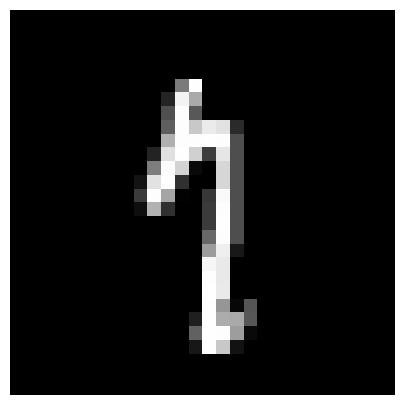

Predicción: 7
Valor real: 1
Confianza: 39.61%


In [28]:
model.eval()
idx = np.random.randint(len(y_test))
plot_number(x_test_num[idx])

with torch.no_grad():
    x_sample = x_test_tensor[idx].unsqueeze(0).to(device)
    output = model(x_sample)
    pred = output.argmax(dim=1).item()
    probs = F.softmax(output, dim=1)[0]
    
print(f'Predicción: {pred}')
print(f'Valor real: {y_test[idx, 0]}')
print(f'Confianza: {probs[pred].item()*100:.2f}%')

## Matriz de Confusión

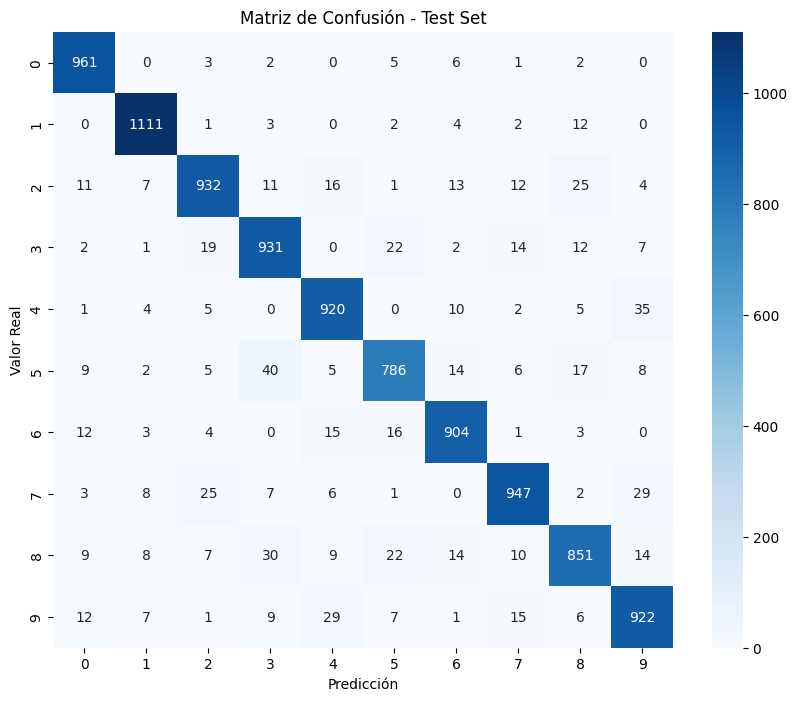

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener todas las predicciones
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# Crear matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Test Set')
plt.show()

## Guardar Modelo

In [30]:
model_path = '../models/modelMNIST.pth'

In [31]:
torch.save(
    model.state_dict(),
    model_path
)

In [ ]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0089,  0.0103, -0.0155,  ..., -0.0078,  0.0297, -0.0197],
                      [-0.0372, -0.0223, -0.0225,  ..., -0.0344,  0.0011, -0.0108],
                      [ 0.0128, -0.0095, -0.0261,  ..., -0.0298, -0.0239,  0.0049],
                      ...,
                      [-0.0286, -0.0030, -0.0110,  ..., -0.0186,  0.0156,  0.0169],
                      [-0.0086,  0.0171,  0.0309,  ...,  0.0183,  0.0228, -0.0191],
                      [-0.0248,  0.0050, -0.0371,  ...,  0.0275,  0.0169,  0.0174]],
                     device='cuda:0')),
             ('0.bias',
              tensor([ 0.0075,  0.0123, -0.0101,  0.0221, -0.0020,  0.0201, -0.0243, -0.0303,
                      -0.0008,  0.0285, -0.0236,  0.0009, -0.0268,  0.0162,  0.0285, -0.0027,
                       0.0110,  0.0458,  0.0024,  0.0346,  0.0114,  0.0373,  0.0348,  0.0409,
                      -0.0208, -0.0300, -0.0193,  0.0308, -0.0288,  0.0375,  0.0281,  0.0281,
  

### Opción 2

In [33]:
model_completo_path = '../models/modelMNIST_completo.pth'

In [34]:
torch.save(model, model_completo_path)